<a href="https://colab.research.google.com/github/zencod-646/firstproject/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [746]:
!pip install tensorflow

In [747]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [748]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [749]:
dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [750]:
##divide the data set to independant and dependant feature
X = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]
X.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [751]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [752]:
import pandas as pd
##feature engineering
geography = pd.get_dummies(dataset['Geography'],drop_first=True)
gender = pd.get_dummies(dataset['Gender'],drop_first=True)

In [753]:
##concatenate these with dataframe
X= X.drop(['Geography','Gender'], axis=1)

In [754]:
X=pd.concat([X,geography,gender],axis=1)

In [755]:
## splitting dataset into training set and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [756]:
##feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train) ##why fit transform only to training dataset?
X_test = sc.transform(X_test)

In [757]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [758]:
X_test


array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [759]:
X_train.shape

(8000, 11)

In [760]:
###create ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [761]:
## initialize the ANN
classifier = Sequential()

In [762]:
##Add the input layer
classifier.add(Dense(units=128,activation = 'relu'))

In [763]:
##adding the first hidden layer
classifier.add(Dense(units=64,activation = 'relu'))
classifier.add(Dropout(0.3))

In [764]:
##adding second hidden layer
classifier.add(Dense(units=32,activation='relu'))
#classifier.add(Dropout(0.3))

In [765]:
##adding the output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [766]:
classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])
##adam uses learning rate of 0.01

In [767]:
##if we want different learning rate
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.0005)

In [768]:
##Early stopping
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [769]:
model_history = classifier.fit(X_train,y_train,validation_split=0.1,batch_size=64,epochs=1000,callbacks = early_stopping  )

Epoch 1/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7781 - loss: 0.4996 - val_accuracy: 0.8125 - val_loss: 0.4275
Epoch 2/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8161 - loss: 0.4263 - val_accuracy: 0.8338 - val_loss: 0.3939
Epoch 3/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8349 - loss: 0.3984 - val_accuracy: 0.8425 - val_loss: 0.3693
Epoch 4/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8451 - loss: 0.3756 - val_accuracy: 0.8575 - val_loss: 0.3473
Epoch 5/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8515 - loss: 0.3619 - val_accuracy: 0.8587 - val_loss: 0.3417
Epoch 6/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8553 - loss: 0.3550 - val_accuracy: 0.8575 - val_loss: 0.3373
Epoch 7/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8553 - loss: 0.3515 - val_accuracy: 0.8650 - val_loss: 0.3339
Epoch 8/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8569 - loss: 0.3

In [770]:
model_history.history.keys()
#what parameters we focused on

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

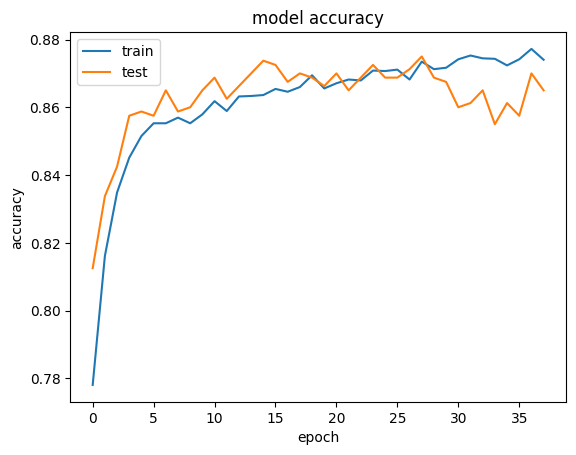

In [771]:
#plot summary history of accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

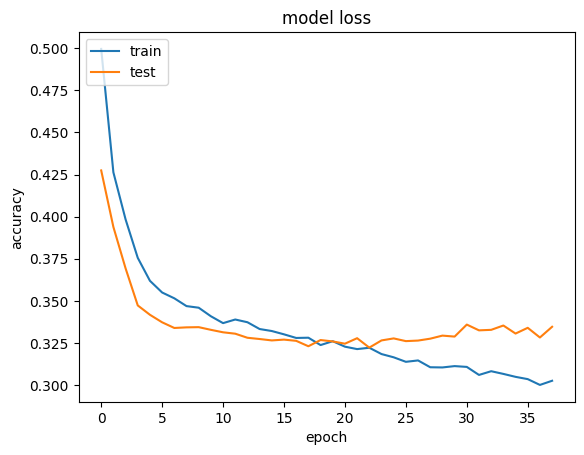

In [772]:
#plot summary history of loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [773]:
###making prediction and evaluating model



In [774]:
##predicting the test result
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [775]:
#make the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[1507,   88],
       [ 202,  203]])

In [776]:
##calculate the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,y_test)

In [777]:
score

0.855

In [778]:
##know about the weights and store them
classifier.get_weights()


[array([[-0.0356238 , -0.0486956 ,  0.02769827, ...,  0.11612103,
          0.07931009,  0.10499369],
        [-0.14139628,  0.22182551,  0.32227513, ...,  0.14832269,
          0.01724852, -0.05518608],
        [-0.15641281,  0.12315121,  0.1015379 , ...,  0.05321972,
         -0.17816523,  0.22843295],
        ...,
        [ 0.04327544, -0.12329894, -0.06249198, ..., -0.00846984,
         -0.22552605,  0.18244651],
        [ 0.07787306,  0.03707421, -0.14695968, ...,  0.01500225,
         -0.03238621,  0.2133695 ],
        [ 0.0120978 , -0.1497354 ,  0.0663311 , ...,  0.12938316,
         -0.09162528,  0.14994216]], dtype=float32),
 array([-0.07474083, -0.03496316, -0.06263594,  0.03749617, -0.01253929,
        -0.02319056,  0.03571662,  0.07991164,  0.04999522, -0.04104616,
         0.0315058 ,  0.00751925,  0.04327001,  0.00791027,  0.023452  ,
         0.00893879, -0.05289066, -0.0655762 ,  0.00695288, -0.02761524,
        -0.02977662,  0.00644848, -0.08855929, -0.00108398, -0.001